## DAĻA A: KLASTERIZĀCIJA

## 1. uzdevums. Sagatavo datus klasterizācijai

## 1.1. Ielādē un sagatavo datus

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


## 1.2. Izvēlies features klasterizācijai


In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)


Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


## 1.3. Normalizē datus

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))


Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

Normalizācija ir ļoti svarīga, par cik K-Means rēķina attālumu un man izvēlētajās kolonās cipari ir sākot no 0.2 (BounceRates) līdz 3398 (ProductRelated_Duration) un ja es neveiktu normalizāciju šos mazos rādītājus 0.2 modelis vienkāŗsi ignorētu, jo tie šķistu nebūtiski salīdzinot ar tūkstošiem. Pēc normalizācijas visas kolonas ir vienādā mērogā jeb modeļa redzējumā vienlīdzīgas vidējais =0 un standartnovirze =1.

## 2. uzdevums. Atrodi optimālo klasteru skaitu (Elbow Method)

## 2.1. Elbow metode

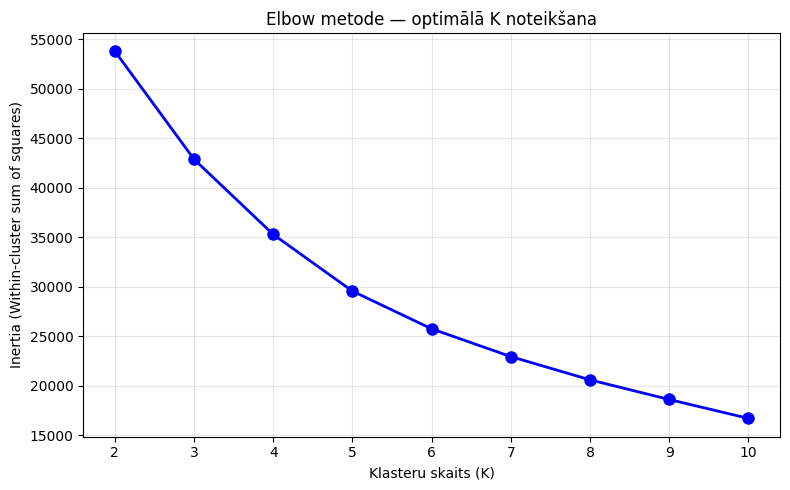

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


K_range ir saraksts ar skaitļiem, kurus mēs izmēģinam renge(2,11) Python valodā. 1- nav iekļauts, jo tas nozīmē visi klienti ir vienā grupā, 11 - nav iekļauts, jo šī grupa mums vairs neko jaunu nedotu. Elkoni idenficēju pie K5, jo manuprtā inerta kritums pēs k5 kļūst lezenāks un tālākie klāsteri papildu uzlabojumus nedod. Tomēr vienas pareizas atbildes nav tik pat labi kāds cits var elkoni identificēt pie k4 vai k6, piemēram. Tā ir interpritācija nevis eksakts aprēķins.

## 3. uzdevums. Veic klasterizāciju un vizualizē

## 3.1. Uztrenē galīgo K-Means modeli

In [5]:
# Izmanto izvēlēto K vērtību (manā gadījumā 5)
K = 5  # <-- nomainiet uz savu izvēlēto vērtību

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())



Klasteru sadalījums:
Cluster
0     644
1    9508
2    1065
3     929
4     184
Name: count, dtype: int64


## 3.2. Vizualizē klasterus ar PCA

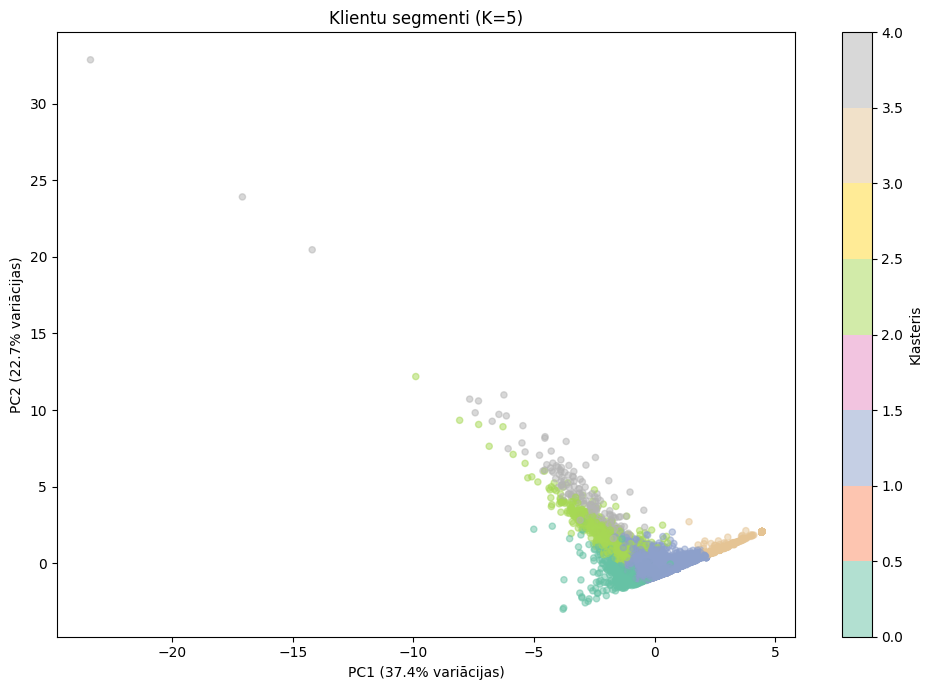

In [6]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()


## 3.3. Klasteru profili un heatmap

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                           0.03                   -0.07   
1                          -0.19                   -0.14   
2                           1.89                    0.35   
3                          -0.45                   -0.24   
4                           1.03                    6.59   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                           0.01        -0.40      -0.59        3.37  
1                          -0.16        -0.25      -0.19       -0.20  
2                           1.66        -0.32      -0.48        0.01  
3                          -0.60         3.24       2.96       -0.32  
4                           1.87        -0.30      -0.43        0.06  


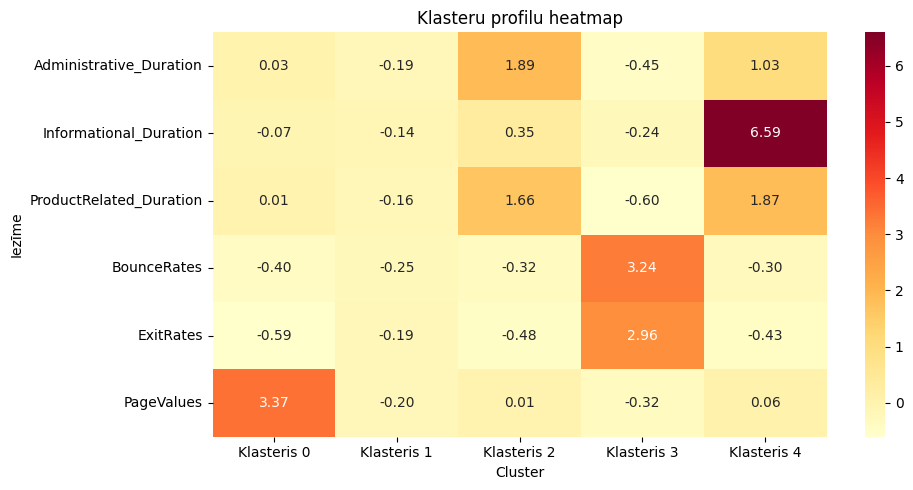

In [7]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()


## 4. uzdevums. Interpretē klasterus biznesa kontekstā

## 4.1. Klasteru raksturojums ar pirkumiem

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.789
1    0.110
2    0.277
3    0.005
4    0.283
Name: Revenue, dtype: float64


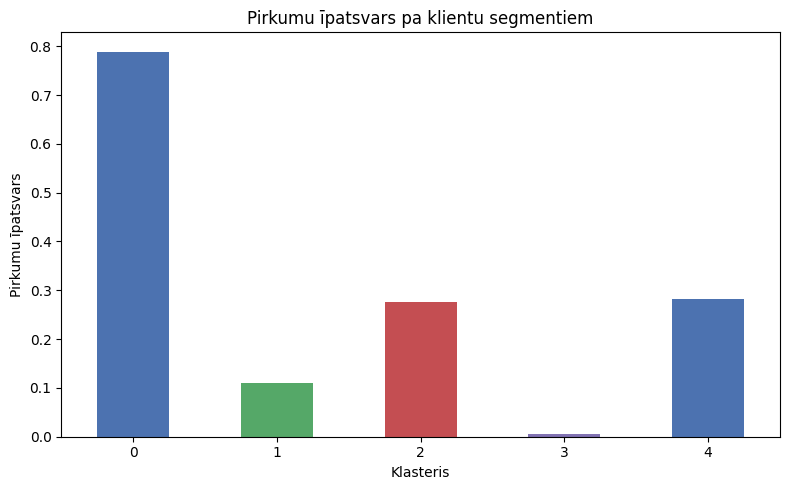

In [8]:
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4.2. Biznesa interpretācija (Markdown šūna)

0.klasteris - Pircēji, pati vērtīgākā no grupām.
1.klasteris - Pelēkie apmeklētāji - atnāca, nedaudz paskatījās aizgāja, grupa kura īpaši ne ar ko neizceļās un arī praktisku pircēju šajā grupā faktiski nav.
2.klasteris - Aktīvie pētītāji -ilgi pēta gan, produktus, gan administratīvās lapas.
3.klasteris - Ātrie aizgājēji - atnāca un uzreiz pazuda, pilnīgi neieinteresēti.
4.klasteris - Pētnieki - lasa visu info, pēta produktus, iespējams salīdzina cenas, otrs augstākais pircēju īpatsvars. Es maksimāli censtos ieinteresēt,  0.,2., un 4.grupu klientus, piedāvājot atlaidi vai kādu interesantu akciju, respektīvi tūlītēju ieguvumu un taupītu ar mārketinga aktivitātēm uz 3.grupas klientiem. 1.grupu - reklāmas materiāli ar atgādinājumu par sevi ar uzsvaru uz jaunumiem, kas varētu pamudināt šo grupu vairāk ieinteresēties un papētīt piedāvājumu.

## DAĻA B: MODEĻU VALIDĀCIJA

## 5. uzdevums. Viena split vs. Cross-validation

## 5.1. Ielādē datus un modeļi

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus (tu tos jau ielādēji, tāpēc varētu būt kļūda)
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)  # Izņem mūsu klasteru kolonu

print(f"Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")


Datu kopa: 12330 rindas, 27 features


## 5.2. Viena train/test split

In [10]:
#Tests 80/20, nav pārāk uzticams, jo ļoti atkarīgskuri klienti pēc nejaušības principa būs iekļauti
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"Viena split F1 score: {single_f1:.3f}")


Viena split F1 score: 0.635


## 5.3. Cross-validation (5-fold)

In [11]:
# Dati tiek sadalīti piecās daļās un katru reizi testēti ar citu testa grupu un no 5 iegūtajiem rezultātiem aprēķināts vidējais, daudz precīzāka metode.
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")


5-fold CV F1 scores: [0.668 0.661 0.652 0.551 0.612]
Vidējais F1: 0.629
Standarta novirze: 0.043


## 5.4. Vizualizācija

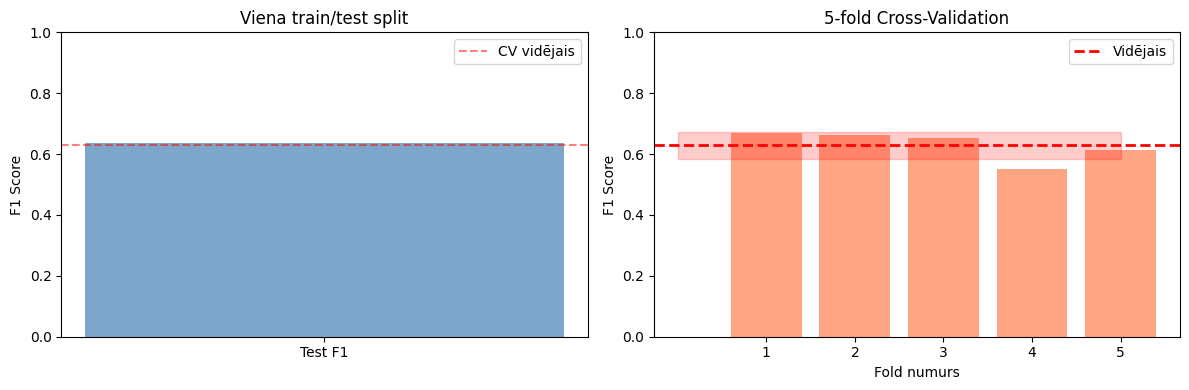

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viena split
axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label='CV vidējais')
axes[0].legend()

# Cross-validation
axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label='Vidējais')
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()


## 5.5. Analīze (Markdown šūna)

Split testā dati ir sadalīti 80/20 klienti tajos ir iekļauti pēc nejaušības principa un tests tiek veikts vienu reizi.
Attiecīgi testa rezultāts ļoti atkarīgs no tā kuri klienti nejauši nokļuva testā, kuri treniņā. CV vidējais tests - klienti 
tiek sadalīti piecās daļās un ar katru nejauši izvēlēto klientu kopu testē atsevišķi, iegūstot 5 rezultātus un no tiem aprēķinot vidējo.
STd novirze parāda cik stabili ir 5 testa rezultāti, ja novirze ir neliela 0.01 tad modelis strādā vienlīdz labi ar visām grupām, ja liela, piemērām, 0.1 tad rezultāts ir atkarīgs no tā kuri klienti ir bijuši testā. Vienas split F1 var dabūt citu rezultātu, pietiks nomainīt random_state 42 uz jebkuru citu skaitli un rezultāts svārstīsies no 0.58 - 0.67. Kas liecina par lielu novirzi un par to, ka dati ir tieši atkarīgi no iekļautajiem klientiem.

## 6. uzdevums. Pipeline un data leakage

## 6.1. Bīstama versija: data leakage

In [15]:
from sklearn.preprocessing import StandardScaler

# ✗ NEPAREIZI - data leakage!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ← Fit uz VISIEM datiem!

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f"F1 ar data leakage: {f1_leaked:.3f}")


F1 ar data leakage: 0.635


## 6.2. Pareizā versija: Pipeline

In [17]:
from sklearn.pipeline import make_pipeline

# ✓ PAREIZI - Pipeline
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Trenēšana ar cross-validation
cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f"F1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")


F1 ar Pipeline: 0.629 ± 0.045


## 6.3. Salīdzinājums

In [18]:
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print(comparison.to_string(index=False))


                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.635258 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.628553     DROŠS! Objektīvs


## 6.4. Skaidrojums (Markdown šūna)

Data leakage ir kad modelis treniņa laikā redz datus, kuri reālā dzīvē tam nebūs pieejami un attiecīgi rezultāts testējot būs labāks nekā tas būs uz reālajiem datiem. Skalers tiek flit pirms split - tas ir kad nav izdalīti atsevišķi treniņa dati un testa dati un modelim tiek iedota arī informācija ar kuru ir domāts to testēt un sanāk, ka modelis pastarpināti jau zin rezultātu nevis prognozē to. Pipeline automātiski sadala treniņa datus un testa datus un modelis mācās uz treniņa datiem un tiek testēts uz testa. Tas ir ļoti svarīgi, jo būtiski ir lai modelis būtu iemācījies prognozēt prasīto, nevis vienkāršī būtu nolasījis atbildes un parādījis ļoti augstu testa rezultātu un dzīvē būtu ļoti vājšs vai bezjēdzīgs.

## 7. uzdevums. GridSearchCV

## 7.1. Parametru tīkls un meklēšana

In [19]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim parametrus
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls — 2 parametri, 3×3 kombinācijas = 9 mēģinājumi
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV: cross-validation + automātiska meklēšana
grid = GridSearchCV(
    pipe, param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,  # Izmanto visas CPU kodolus
    verbose=1
)

# Trenēšana (tikai uz training datiem!)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")
print(f"Test F1 (ar labākajiem parametriem): {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.653
Test F1 (ar labākajiem parametriem): 0.629


## Labākais CV F1 (treniņā): 0.653

In [22]:
# Kādi bija VISIEM parametriem?
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("Top 5 parametru kombinācijas:")
print(results_table.head())



Top 5 parametru kombinācijas:
   param_randomforestclassifier__n_estimators  \
8                                         200   
7                                         100   
5                                         200   
4                                         100   
6                                          50   

   param_randomforestclassifier__max_depth  mean_test_score  std_test_score  
8                                       20         0.653164        0.012239  
7                                       20         0.649086        0.017458  
5                                       10         0.647174        0.011353  
4                                       10         0.645475        0.008885  
6                                       20         0.643574        0.013674  


## 7.3. Vizualizācija: heatmap

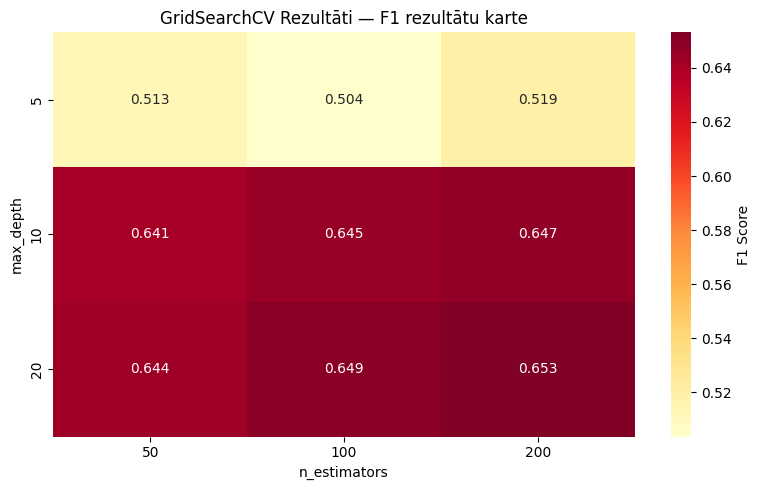

In [23]:
# Pivot tabula — n_estimators kolonnas, max_depth rindas
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)
plt.title('GridSearchCV Rezultāti — F1 rezultātu karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()


## 7.4. Interpretācija (Markdown šūna)

Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.653
Test F1 (ar labākajiem parametriem): 0.629
Starpība starp labāko un sliktāko kombināciju bija tikai 0,149, tā ir diezgan liela, 
Karstās zonas ir un pēc karstajām zonām var secināt, ka svarīgākais ir koku dziļums, jo dziļāki, jo lielākas sakritības neatkarīgi no to daudzuma. GridSearchCV uzrāda nedaudz augstākus rezultātus, ka pirms tam manuāli izvēlētie dati CV F1(0,653) un Test F1 (5fold) (0,629), kas norāda, ka modelis treniņā strādā nedaudz labāk nekā uz jauniem datiem.
